# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [6]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN


df = pd.read_csv("AAPL (1).csv")

df.columns = df.columns.str.lower()

df["date"] = pd.to_datetime(df["date"])


df = df.set_index("date").sort_index()


df = df[["open", "high", "low", "close", "volume"]]

df.loc[df["volume"] == 0, :] = np.nan

df.head()

,open,high,low,close,volume
date,,,,,
2015-01-02,27.847500,27.860001,26.837500,27.332500,212818400.0
2015-01-05,27.072500,27.162500,26.352501,26.562500,257142000.0
2015-01-06,26.635000,26.857500,26.157499,26.565001,263188400.0
2015-01-07,26.799999,27.049999,26.674999,26.937500,160423600.0
2015-01-08,27.307501,28.037500,27.174999,27.972500,237458000.0


In [7]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [9]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.

# return_1     = ...
# return_5     = ...
# log_return_1 = ...

df["return_1"] = df["close"].pct_change(1)

df["return_5"] = df["close"].pct_change(5)


df["log_return_1"] = np.log(df["close"] / df["close"].shift(1))

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [10]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df["sma_20"] = df["close"].rolling(window=20).mean()
df["sma_50"] = df["close"].rolling(window=50).mean()
df["sma_200"] = df["close"].rolling(window=200).mean()
df["sma_ratio_20"] = df["close"] / df["sma_20"] - 1
df["sma_ratio_50"] = df["close"] / df["sma_50"] - 1

/tmp/ipykernel_1405/457340630.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last("730D")


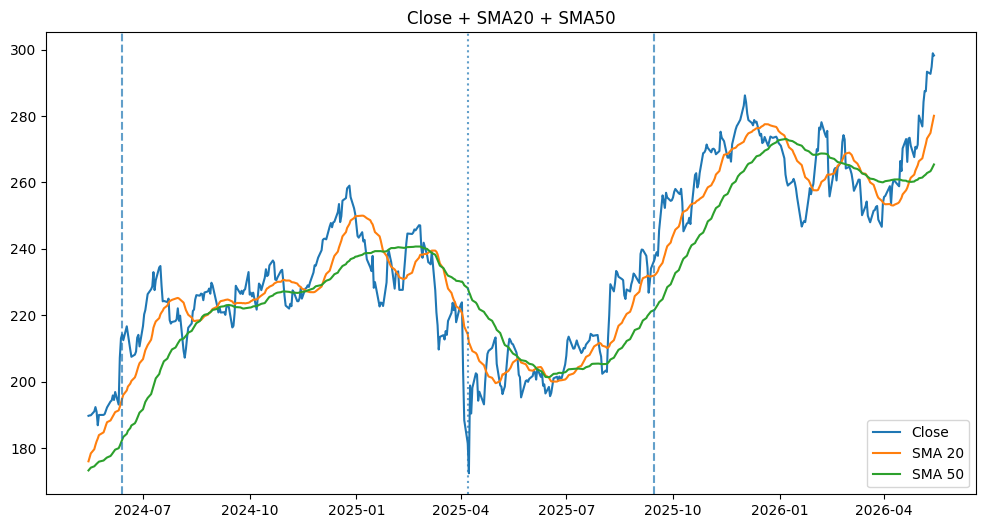

In [11]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

recent = df.last("730D")

cross = np.sign(df["sma_50"] - df["sma_200"])
golden = df.index[(cross.shift(1) <= 0) & (cross > 0)]
death  = df.index[(cross.shift(1) >= 0) & (cross < 0)]

plt.figure(figsize=(12, 6))
plt.plot(recent.index, recent["close"], label="Close")
plt.plot(recent.index, recent["sma_20"], label="SMA 20")
plt.plot(recent.index, recent["sma_50"], label="SMA 50")

for d in golden:
    if d in recent.index:
        plt.axvline(d, ls="--", alpha=0.7)

for d in death:
    if d in recent.index:
        plt.axvline(d, ls=":", alpha=0.7)

plt.legend()
plt.title("Close + SMA20 + SMA50")
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [12]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20

df["ema_12"] = df["close"].ewm(span=12, adjust=False).mean()
df["ema_20"] = df["close"].ewm(span=20, adjust=False).mean()
df["ema_26"] = df["close"].ewm(span=26, adjust=False).mean()
df["ema_ratio_20"] = df["close"] / df["ema_20"] - 1

/tmp/ipykernel_1405/1339916126.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last("365D")


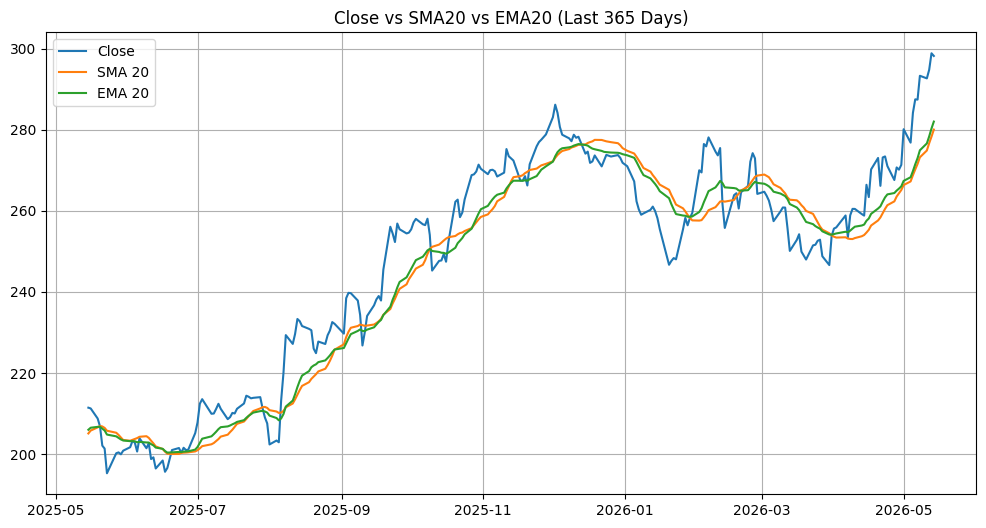

In [13]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA
recent = df.last("365D")

plt.figure(figsize=(12, 6))
plt.plot(recent.index, recent["close"], label="Close")
plt.plot(recent.index, recent["sma_20"], label="SMA 20")
plt.plot(recent.index, recent["ema_20"], label="EMA 20")

plt.title("Close vs SMA20 vs EMA20 (Last 365 Days)")
plt.legend()
plt.grid(True)
plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [14]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

# delta    = ...
# gain     = ...
# loss     = ...
# avg_gain = ...
# avg_loss = ...
# rs       = ...
# df['rsi_14'] = ...
delta = df["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.ewm(com=14-1, adjust=False).mean()
avg_loss = loss.ewm(com=14-1, adjust=False).mean()

rs = avg_gain / avg_loss

df["rsi_14"] = (100 - (100 / (1 + rs))) / 100

/tmp/ipykernel_1405/1688750900.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last("365D")


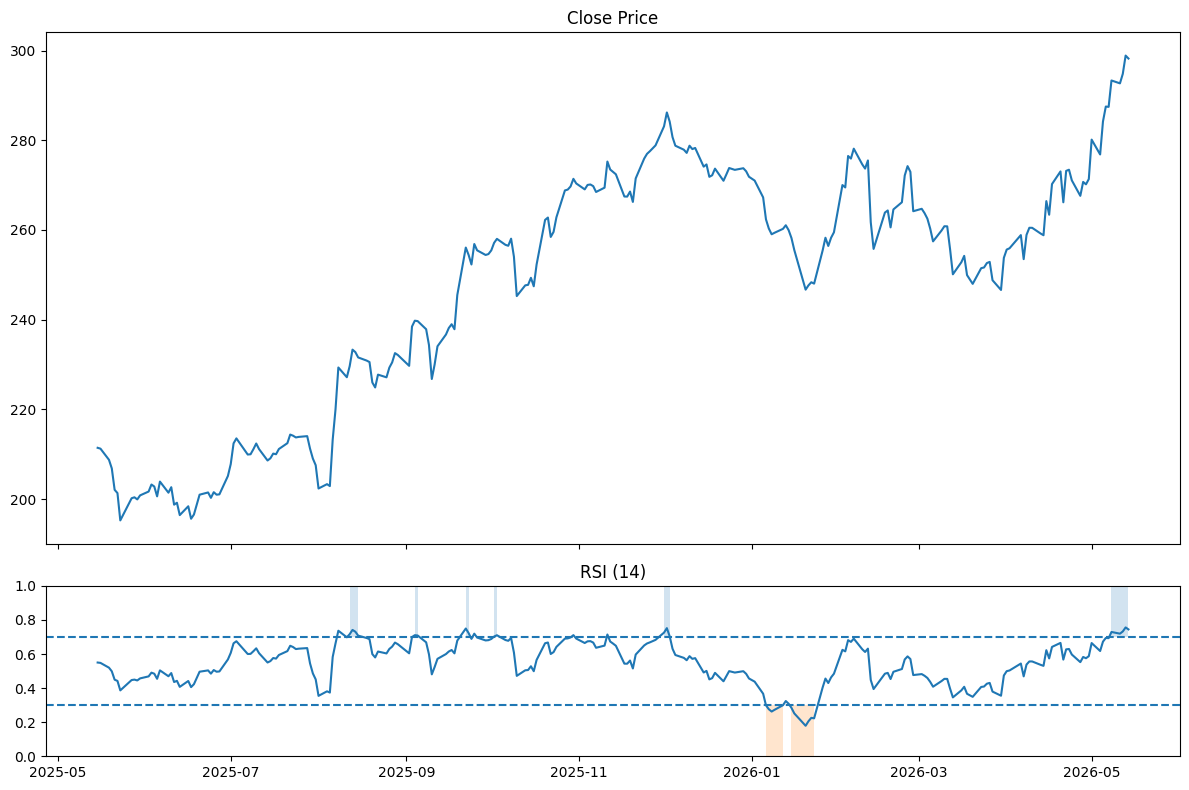

In [15]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green
import matplotlib.pyplot as plt

recent = df.last("365D")

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.plot(recent.index, recent["close"])
ax1.set_title("Close Price")


ax2.plot(recent.index, recent["rsi_14"])
ax2.axhline(0.70, ls="--")
ax2.axhline(0.30, ls="--")

ax2.fill_between(recent.index, 0.70, 1.0,
                 where=recent["rsi_14"] >= 0.70,
                 alpha=0.2)

ax2.fill_between(recent.index, 0.0, 0.30,
                 where=recent["rsi_14"] <= 0.30,
                 alpha=0.2)

ax2.set_ylim(0, 1)
ax2.set_title("RSI (14)")

plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [16]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df["macd"] = df["ema_12"] - df["ema_26"]


df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()


df["macd_hist"] = df["macd"] - df["macd_signal"]

/tmp/ipykernel_1405/3788890117.py:3: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last("365D")


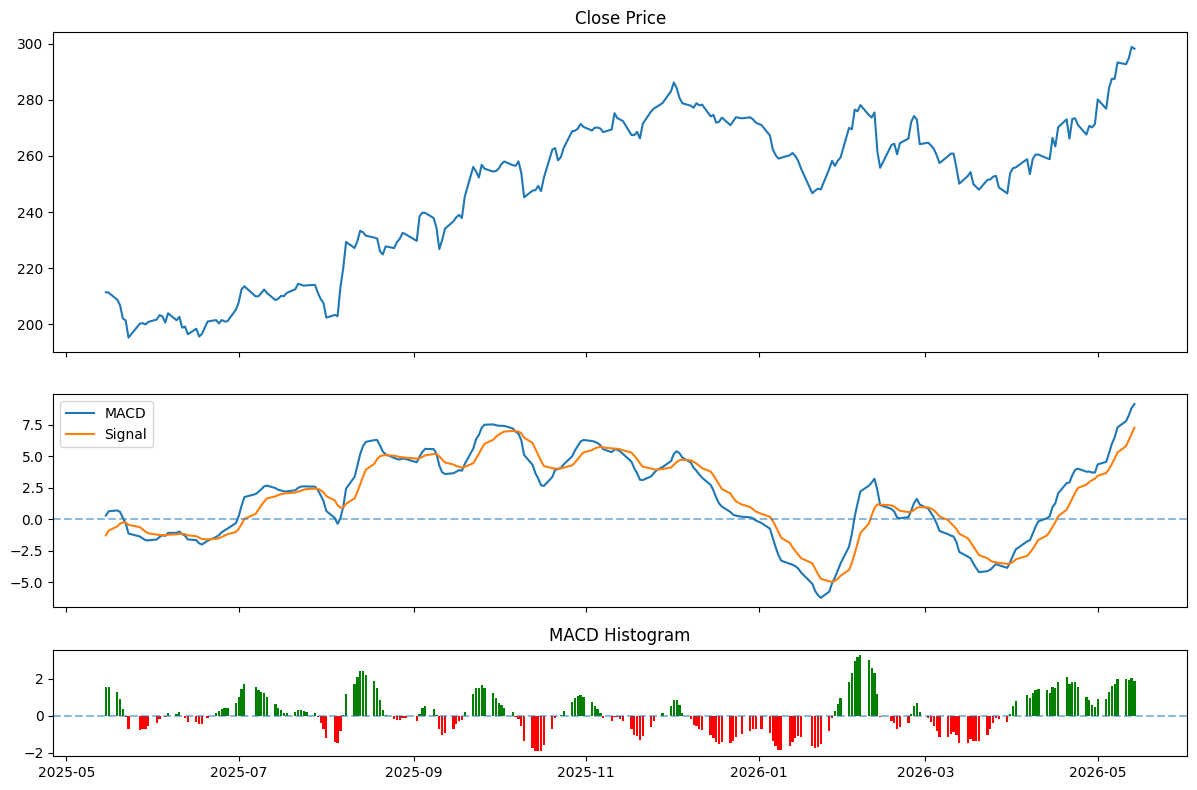

In [17]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign

recent = df.last("365D")

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 2, 1]}
)

ax1.plot(recent.index, recent["close"])
ax1.set_title("Close Price")

ax2.plot(recent.index, recent["macd"], label="MACD")
ax2.plot(recent.index, recent["macd_signal"], label="Signal")
ax2.axhline(0, ls="--", alpha=0.5)
ax2.legend()

ax3.bar(
    recent.index,
    recent["macd_hist"],
    color=["g" if x >= 0 else "r" for x in recent["macd_hist"]]
)
ax3.axhline(0, ls="--", alpha=0.5)
ax3.set_title("MACD Histogram")

plt.tight_layout()
plt.show()

## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [18]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

# 20-day rolling standard deviation
rolling_std = df["close"].rolling(20).std()

# Bollinger Bands
df["bb_upper"] = df["sma_20"] + 2 * rolling_std
df["bb_lower"] = df["sma_20"] - 2 * rolling_std

# Band width
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["sma_20"]

# %B
df["bb_pct_b"] = (
    (df["close"] - df["bb_lower"]) /
    (df["bb_upper"] - df["bb_lower"])
).clip(0, 1)

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [19]:
# TODO 6 — Compute roc_5 and roc_10

# df['roc_5']  = ...
# df['roc_10'] = ...
df["roc_5"] = df["close"].pct_change(5)
df["roc_10"] = df["close"].pct_change(10)

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [20]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

# prev_close = ...
# true_range = ...
# df['atr_14']    = ...
# df['atr_ratio'] = ...

# Previous day's close
prev_close = df["close"].shift(1)

# True Range
true_range = pd.concat([
    df["high"] - df["low"],
    (df["high"] - prev_close).abs(),
    (df["low"] - prev_close).abs()
], axis=1).max(axis=1)

# ATR(14) using Wilder smoothing
df["atr_14"] = true_range.ewm(com=13, adjust=False).mean()

# ATR relative to price
df["atr_ratio"] = df["atr_14"] / df["close"]

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [21]:
# TODO 8.1 — Compute stoch_k and stoch_d


# 14-period lowest low and highest high
lowest_low = df["low"].rolling(14).min()
highest_high = df["high"].rolling(14).max()

# %K
df["stoch_k"] = (df["close"] - lowest_low) / (highest_high - lowest_low)

# %D (3-period SMA of %K)
df["stoch_d"] = df["stoch_k"].rolling(3).mean()

/tmp/ipykernel_1405/1431569420.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last("365D")


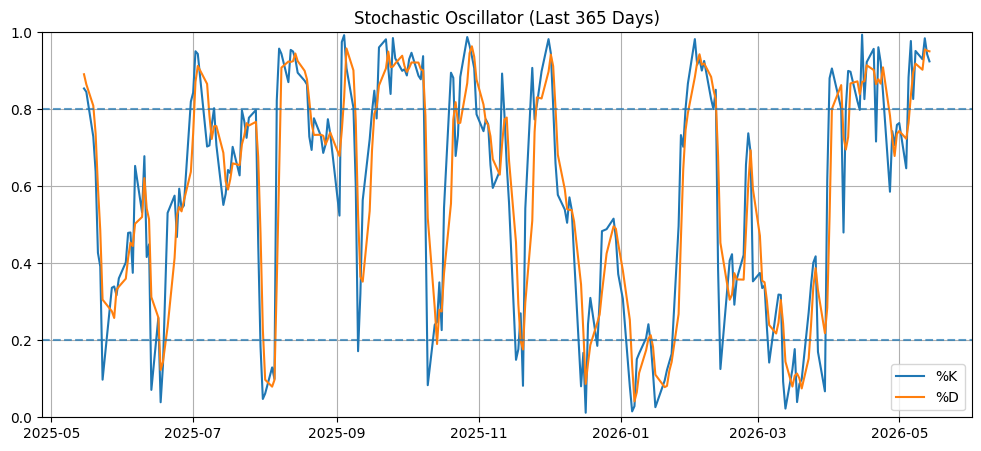

In [22]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal

recent = df.last("365D")

plt.figure(figsize=(12, 5))
plt.plot(recent.index, recent["stoch_k"], label="%K")
plt.plot(recent.index, recent["stoch_d"], label="%D")

plt.axhline(0.80, ls="--", alpha=0.7)
plt.axhline(0.20, ls="--", alpha=0.7)

plt.title("Stochastic Oscillator (Last 365 Days)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [23]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

# direction       = ...
# df['obv']       = ...
# df['obv_change']= ...
direction = np.sign(df["close"].diff())
df["obv"] = (direction * df["volume"]).fillna(0).cumsum()
df["obv_change"] = df["obv"].pct_change()

## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [24]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

# typical_price   = ...
# tp_vol          = ...
# df['vwap']       = ...
# df['vwap_ratio'] = ...
# Typical Price
typical_price = (df["high"] + df["low"] + df["close"]) / 3


tp_vol = typical_price * df["volume"]


df["vwap"] = (
    tp_vol.rolling(20).sum() /
    df["volume"].rolling(20).sum()
)


df["vwap_ratio"] = df["close"] / df["vwap"] - 1

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [25]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
    'future_return',
    'target_direction',
]

In [27]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

# df['future_return']    = ...
# df['target_direction'] = ...

# required = ...
# df       = ...
# df_clean = ...

# out_path = ...
# df_clean.to_csv(...)
# print(...)
# df_clean[required].describe().round(4)
df["future_return"] = df["close"].shift(-1) / df["close"] - 1
df["target_direction"] = (df["future_return"] > 0).astype(int)


required = [
    "return_1", "return_5", "log_return_1",
    "sma_ratio_20", "sma_ratio_50",
    "ema_ratio_20",
    "rsi_14",
    "macd", "macd_signal", "macd_hist",
    "bb_width", "bb_pct_b",
    "roc_5", "roc_10",
    "atr_ratio",
    "stoch_k", "stoch_d",
    "obv_change",
    "vwap_ratio",
    "future_return", "target_direction"
]

df = df.replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna(subset=required).reset_index()

out_path = "AAPL_features.csv"

df_clean.to_csv(out_path, index=False)

print("Saved to:", out_path)
print("Shape:", df_clean.shape)

display(df_clean[required].describe().round(4))


Saved to: AAPL_features.csv
Shape: (2808, 38)


,return_1,return_5,log_return_1,sma_ratio_20,sma_ratio_50,ema_ratio_20,rsi_14,macd,macd_signal,macd_hist,...,bb_pct_b,roc_5,roc_10,atr_ratio,stoch_k,stoch_d,obv_change,vwap_ratio,future_return,target_direction
count,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,...,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000,2808.0000
mean,0.0010,0.0047,0.0008,0.0078,0.0202,0.0073,0.5471,0.5966,0.5878,0.0089,...,0.5784,0.0047,0.0093,0.0224,0.5895,0.5892,-0.0328,0.0093,0.0010,0.5278
std,0.0181,0.0383,0.0181,0.0421,0.0692,0.0363,0.1298,2.4214,2.2539,0.7630,...,0.3091,0.0383,0.0535,0.0083,0.3089,0.2894,1.5677,0.0408,0.0181,0.4993
min,-0.1286,-0.2275,-0.1377,-0.1861,-0.2482,-0.1813,0.1789,-10.6409,-8.3474,-4.3390,...,0.0000,-0.2275,-0.2294,0.0091,0.0000,0.0059,-60.7091,-0.1633,-0.1286,0.0000
25%,-0.0074,-0.0174,-0.0074,-0.0179,-0.0227,-0.0140,0.4498,-0.5467,-0.4503,-0.2563,...,0.3088,-0.0174,-0.0232,0.0168,0.3088,0.3201,-0.0339,-0.0165,-0.0074,0.0000
50%,0.0009,0.0061,0.0009,0.0117,0.0240,0.0112,0.5517,0.3980,0.3758,0.0101,...,0.6432,0.0061,0.0122,0.0204,0.6598,0.6560,0.0064,0.0124,0.0008,1.0000
75%,0.0099,0.0271,0.0098,0.0363,0.0673,0.0310,0.6431,1.7570,1.6800,0.2816,...,0.8456,0.0271,0.0434,0.0256,0.8749,0.8527,0.0357,0.0376,0.0098,1.0000
max,0.1533,0.1841,0.1426,0.1475,0.2796,0.1337,0.9040,8.9481,8.3104,3.3104,...,1.0000,0.1841,0.2268,0.0776,1.0000,0.9977,25.8636,0.1494,0.1533,1.0000


In [28]:
# TODO 11.2 (Challenge) — Run the full pipeline for atleast one downloaded symbols
# To process for all symbol change the symbol above rerun all cells to get features of that symbol.
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

# summary = []
# for csv_path in ...:
#     sym = ...
#     try:
#         raw       = ...
#         # ... use the computed indicators above ...
#         processed = ...
#         # ... save to PROCESSED_DIR ...
#         summary.append({...})
#     except Exception as e:
#         summary.append({'symbol': sym, 'error': str(e)})

# pd.DataFrame(summary)


summary = []

for csv_path in RAW_DIR.glob("*.csv"):

    sym = csv_path.stem

    try:
        raw = pd.read_csv(csv_path)

        rows_raw = len(raw)


        raw.columns = raw.columns.str.lower()
        raw["date"] = pd.to_datetime(raw["date"])
        raw = raw.set_index("date").sort_index()


        raw = raw.replace([np.inf, -np.inf], np.nan)

        processed = raw.dropna(subset=required).reset_index()

        rows_processed = len(processed)

        out_path = PROCESSED_DIR / f"{sym}_features.csv"
        processed.to_csv(out_path, index=False)

        summary.append({
            "symbol": sym,
            "rows_raw": rows_raw,
            "rows_processed": rows_processed,
            "drop_pct": round(
                100 * (rows_raw - rows_processed) / rows_raw, 2
            )
        })

    except Exception as e:

        summary.append({
            "symbol": sym,
            "error": str(e)
        })

summary_df = pd.DataFrame(summary)

print(summary_df)

summary_df

Empty DataFrame
Columns: []
Index: []


""


---
